# Experiment: Guy Datasets Deconvolution (Latent Dimension = 4)

Objective:
- Use the same dataset family and file conventions as `04_load_for_guy_umap.ipynb`.
- Build an `AnnData` object and perform probabilistic archetypal deconvolution with latent size `4`.
- Store labels/weights in `obs` and embeddings in `obsm`, then visualize with Seaborn and Scanpy UMAP.

In [30]:
from __future__ import annotations

from pathlib import Path
import re
import sys
import time
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import anndata as ad
from tqdm.auto import tqdm
from IPython.display import display, HTML

import torch
from torch.utils.data import DataLoader, TensorDataset

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'pyproject.toml').exists(), 'Could not find repo root with pyproject.toml'

SRC_PATH = REPO_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from cytof_archetypes.models import (
    ProbabilisticArchetypalAutoencoder,
    gaussian_nll,
    entropy_penalty,
    diversity_penalty,
    variance_regularization,
)

sns.set_theme(context='notebook', style='whitegrid')
plt.ioff()
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['figure.autolayout'] = False
plt.rcParams['figure.constrained_layout.use'] = True

display(HTML("""
<style>
html, body {
  scroll-behavior: auto !important;
}
.jp-Notebook,
.jp-NotebookPanel-notebook,
.jp-Cell,
.jp-OutputArea,
.jp-OutputArea-child,
.jp-RenderedHTMLCommon,
.output,
.output_area {
  overflow-anchor: none !important;
}
.jp-OutputArea-output,
.output_area {
  overflow-x: auto;
  max-width: 100%;
}
.jp-OutputArea pre,
.jp-OutputArea-output pre {
  white-space: pre-wrap;
}
</style>
"""))


## Dataset Configuration (Matched to 04_load_for_guy_umap)

In [31]:
# Same dataset root used by the reference notebook.
DATA_DIR = Path('/Users/ronguy/Dropbox/CyTOF_Breast/for_guy')

# Same file-family convention as the reference notebook.
FILE_VARIANT = 'normalized_not_scaled'   # 'raw' | 'normalized_not_scaled' | 'batch_corrected' | 'all'
FILE_EXTENSION = 'parquet'
SAMPLE_ID_REGEX = r'_([0-9]+(?:\.[0-9]+)?)$'
EXCLUDE_SAMPLE_IDS_ENDING_WITH_DOT2 = True
EXCLUDED_MARKERS = ['H3', 'H4', 'H3.3']

# Loading and preprocessing controls
TARGET_TOTAL_CELLS = 200_000
RANDOM_STATE = 42
CLIP_MARKERS_TO_ZERO_AND_PERCENTILE = True
CLIP_UPPER_PERCENTILE = 99.9
APPLY_ARCSINH = False
ARCSINH_COFACTOR = 5.0

# Deconvolution setup
LATENT_DIM = 4
BATCH_SIZE = 1024
MAX_EPOCHS = 120
PATIENCE = 20
LR = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
LAMBDA_ENTROPY = 1e-3
LAMBDA_DIVERSITY = 1e-3
LAMBDA_VAR = 1e-5

# Training reuse controls
REUSE_EXISTING_MODEL = True
FORCE_RETRAIN = False
MODEL_CACHE_DIR = REPO_ROOT / 'outputs' / 'guy_latent4_cache'
MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Device preference (MPS when available).
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

print(f'Using device: {DEVICE}')
print(f'Dataset directory exists: {DATA_DIR.exists()}')
print(f'Model reuse: REUSE_EXISTING_MODEL={REUSE_EXISTING_MODEL}, FORCE_RETRAIN={FORCE_RETRAIN}')


# Fast UMAP controls (fit on subset, project to all)
UMAP_N_NEIGHBORS = 20
UMAP_MIN_DIST = 0.2
UMAP_METRIC = 'euclidean'
UMAP_FIT_SUBSET_CELLS = 20_000
UMAP_TRANSFORM_ALL_CELLS = True
UMAP_PROJECTION_MODE = 'nn_interp'   # 'nn_interp' (fast) | 'umap_transform' (exact, slower)
UMAP_NN_INTERP_K = 5
UMAP_TRANSFORM_CHUNK_SIZE = 100_000
UMAP_RANDOM_STATE = None
UMAP_LOW_MEMORY = False
UMAP_VERBOSE = True
UMAP_USE_PCA_PRECOMPRESSION = True
UMAP_PCA_COMPONENTS = 4


Using device: mps
Dataset directory exists: True
Model reuse: REUSE_EXISTING_MODEL=True, FORCE_RETRAIN=False


In [32]:
def build_glob_pattern(file_variant: str, file_extension: str) -> str:
    ext = file_extension.lstrip('.')
    if file_variant == 'all':
        return f'*.{ext}'
    return f'{file_variant}_*.{ext}'

def parse_sample_id(file_path: Path, sample_id_regex: str) -> str:
    stem = file_path.stem
    m = re.search(sample_id_regex, stem)
    if m is not None:
        return m.group(1)
    fallback = re.findall(r'[0-9]+(?:\.[0-9]+)?', stem)
    if fallback:
        return fallback[-1]
    raise ValueError(f'Could not parse sample id from filename: {file_path.name}')

def marker_is_excluded(marker: str, excluded_markers: list[str]) -> bool:
    marker_norm = marker.strip().lower()
    excluded_norm = {m.strip().lower() for m in excluded_markers}
    return marker_norm in excluded_norm

def load_table(path: Path) -> pd.DataFrame:
    suf = path.suffix.lower()
    if suf == '.parquet':
        return pd.read_parquet(path)
    if suf in {'.csv', '.txt'}:
        return pd.read_csv(path)
    if suf == '.tsv':
        return pd.read_csv(path, sep='\t')
    raise ValueError(f'Unsupported extension: {path.suffix}')

def stratified_subsample_indices(labels: np.ndarray, n_target: int, rng: np.random.Generator) -> np.ndarray:
    labels = np.asarray(labels)
    n = len(labels)
    if n_target >= n:
        return np.arange(n, dtype=np.int64)

    df_idx = pd.DataFrame({'label': labels, 'idx': np.arange(n, dtype=np.int64)})
    selected = []

    vc = df_idx['label'].value_counts()
    proportions = vc / vc.sum()
    alloc = (proportions * n_target).astype(int)
    alloc = alloc.clip(lower=1)

    while int(alloc.sum()) > n_target:
        largest = alloc.idxmax()
        if alloc[largest] > 1:
            alloc[largest] -= 1
        else:
            break
    while int(alloc.sum()) < n_target:
        smallest = alloc.idxmin()
        alloc[smallest] += 1

    for label, k in alloc.items():
        sub = df_idx[df_idx['label'] == label]['idx'].to_numpy()
        k_eff = min(int(k), len(sub))
        chosen = rng.choice(sub, size=k_eff, replace=False)
        selected.append(chosen)

    out = np.concatenate(selected)
    if len(out) > n_target:
        out = rng.choice(out, size=n_target, replace=False)
    return np.sort(out.astype(np.int64))


def fast_umap_transform_to_obsm(
    adata: ad.AnnData,
    input_rep: str,
    output_rep: str,
    group_obs: str | None = None,
    fit_subset_n: int = 20000,
    n_neighbors: int = 20,
    min_dist: float = 0.2,
    metric: str = 'euclidean',
    random_state: int | None = None,
    low_memory: bool = False,
    verbose: bool = True,
    use_pca_precompression: bool = True,
    pca_components: int = 10,
    transform_chunk_size: int = 25000,
) -> dict:
    """Fast UMAP helper: fit on subset, then apply chunked umap_transform to all cells.

    Stores 2D embedding at adata.obsm[output_rep]. Returns fit metadata.
    """
    try:
        import umap
    except ImportError as exc:
        raise ImportError('umap-learn is required: pip install umap-learn') from exc

    from sklearn.decomposition import PCA

    if input_rep == 'X':
        X_all = np.asarray(adata.X, dtype=np.float32)
    elif input_rep in adata.obsm:
        X_all = np.asarray(adata.obsm[input_rep], dtype=np.float32)
    else:
        raise KeyError(
            f"Input representation not found. Use 'X' for adata.X or a key in adata.obsm. Got: {input_rep}"
        )

    n_cells = X_all.shape[0]

    rng = np.random.default_rng(42 if random_state is None else random_state)
    fit_n = min(int(fit_subset_n), n_cells)

    if group_obs is not None:
        if group_obs not in adata.obs.columns:
            raise KeyError(f"group_obs column not found in adata.obs: {group_obs}")
        labels = adata.obs[group_obs].astype(str).to_numpy()
        fit_idx = stratified_subsample_indices(labels, fit_n, rng)
    else:
        fit_idx = np.sort(rng.choice(n_cells, size=fit_n, replace=False).astype(np.int64))

    X_fit = X_all[fit_idx]

    pca_model = None
    X_fit_model = X_fit
    pca_n = None

    if use_pca_precompression:
        pca_n = min(int(pca_components), X_all.shape[1], max(2, X_fit.shape[0] - 1))
        if pca_n >= 2:
            pca_model = PCA(n_components=pca_n, random_state=(42 if random_state is None else random_state))
            pca_model.fit(X_fit)
            X_fit_model = pca_model.transform(X_fit).astype(np.float32, copy=False)

    umap_model = umap.UMAP(
        n_neighbors=int(n_neighbors),
        min_dist=float(min_dist),
        metric=metric,
        random_state=random_state,
        transform_mode='embedding',
        low_memory=bool(low_memory),
        verbose=bool(verbose),
    )

    _ = umap_model.fit_transform(X_fit_model).astype(np.float32, copy=False)

    embedding = np.empty((n_cells, 2), dtype=np.float32)
    starts = list(range(0, n_cells, int(transform_chunk_size)))
    for start in tqdm(starts, desc=f'UMAP transform -> {output_rep}', dynamic_ncols=False):
        stop = min(start + int(transform_chunk_size), n_cells)
        x_chunk = X_all[start:stop]
        if pca_model is not None:
            x_chunk = pca_model.transform(x_chunk).astype(np.float32, copy=False)
        embedding[start:stop] = umap_model.transform(x_chunk)

    adata.obsm[output_rep] = embedding

    return {
        'fit_n': int(fit_n),
        'n_cells': int(n_cells),
        'input_rep': input_rep,
        'output_rep': output_rep,
        'pca_components_used': None if pca_model is None else int(pca_n),
    }


In [33]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Data directory not found: {DATA_DIR}')

pattern = build_glob_pattern(FILE_VARIANT, FILE_EXTENSION)
files = sorted(DATA_DIR.glob(pattern))
if len(files) == 0:
    raise FileNotFoundError(f'No files matched pattern {pattern!r} in {DATA_DIR}')

def _sort_key(p: Path):
    sid = parse_sample_id(p, SAMPLE_ID_REGEX)
    try:
        return (float(sid), p.name)
    except ValueError:
        return (np.inf, p.name)

files = sorted(files, key=_sort_key)

if EXCLUDE_SAMPLE_IDS_ENDING_WITH_DOT2:
    kept, excluded = [], []
    for fp in files:
        sid = parse_sample_id(fp, SAMPLE_ID_REGEX)
        if str(sid).endswith('.2'):
            excluded.append(fp)
        else:
            kept.append(fp)
    files = kept
    if excluded:
        print(f'Excluded {len(excluded)} files ending with .2')
        for fp in excluded:
            print(' -', fp.name)

if len(files) == 0:
    raise RuntimeError('All files were excluded.')

print(f'Using {len(files)} files with pattern {pattern!r}:')
for fp in files:
    print(' -', fp.name)

Excluded 2 files ending with .2
 - normalized_not_scaled_14.2.parquet
 - normalized_not_scaled_18.2.parquet
Using 15 files with pattern 'normalized_not_scaled_*.parquet':
 - normalized_not_scaled_4.parquet
 - normalized_not_scaled_4.1.parquet
 - normalized_not_scaled_5.parquet
 - normalized_not_scaled_7.parquet
 - normalized_not_scaled_7.1.parquet
 - normalized_not_scaled_8.parquet
 - normalized_not_scaled_8.1.parquet
 - normalized_not_scaled_11.parquet
 - normalized_not_scaled_13.parquet
 - normalized_not_scaled_14.parquet
 - normalized_not_scaled_15.parquet
 - normalized_not_scaled_17.parquet
 - normalized_not_scaled_18.parquet
 - normalized_not_scaled_19.parquet
 - normalized_not_scaled_20.parquet


In [34]:
rng = np.random.default_rng(RANDOM_STATE)
per_file_target = max(1, TARGET_TOTAL_CELLS // len(files))

sampled_tables = []
sampled_meta = []
common_markers = None

for fp in tqdm(files, desc='Loading and balanced sampling'):
    sid = parse_sample_id(fp, SAMPLE_ID_REGEX)
    df = load_table(fp)

    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    marker_cols = [c for c in numeric_cols if not marker_is_excluded(c, EXCLUDED_MARKERS)]
    if len(marker_cols) == 0:
        print(f'Warning: skipping {fp.name} (no usable marker columns).')
        continue

    if len(df) <= per_file_target:
        idx = np.arange(len(df), dtype=np.int64)
    else:
        idx = rng.choice(len(df), size=per_file_target, replace=False)

    sampled = df.iloc[idx][marker_cols].copy()

    if common_markers is None:
        common_markers = list(sampled.columns)
    else:
        common_set = set(sampled.columns)
        common_markers = [c for c in common_markers if c in common_set]

    sampled_tables.append(sampled)
    sampled_meta.append(pd.DataFrame({
        'source_file': fp.name,
        'source_row_index': idx,
        'sample_id': sid,
    }))

if len(sampled_tables) == 0:
    raise RuntimeError('No data loaded after filtering.')
if common_markers is None or len(common_markers) == 0:
    raise RuntimeError('No common marker columns across loaded files.')

common_markers = sorted(common_markers, key=lambda x: str(x).lower())
sampled_tables = [t[common_markers].reset_index(drop=True) for t in sampled_tables]
meta_all = pd.concat(sampled_meta, axis=0, ignore_index=True)
markers_df = pd.concat(sampled_tables, axis=0, ignore_index=True)
if len(markers_df) != len(meta_all):
    raise RuntimeError('Marker and metadata row counts do not match.')

X = markers_df.to_numpy(dtype=np.float32, copy=False)
if APPLY_ARCSINH:
    X = np.arcsinh(X / ARCSINH_COFACTOR)

if CLIP_MARKERS_TO_ZERO_AND_PERCENTILE:
    upper = np.percentile(X, CLIP_UPPER_PERCENTILE, axis=0)
    X = np.clip(X, 0.0, upper[None, :]).astype(np.float32, copy=False)
    print(f'Applied clipping to [0, p{CLIP_UPPER_PERCENTILE}] per marker.')

cell_ids = np.array([
    f"{meta_all.loc[i, 'source_file']}__{int(meta_all.loc[i, 'source_row_index'])}"
    for i in range(len(meta_all))
], dtype=object)
meta_all['cell_id'] = cell_ids

print('Loaded matrix shape:', X.shape)
print('Number of markers:', len(common_markers))
display(meta_all.head())
display(pd.Series(meta_all['sample_id']).value_counts().sort_index().to_frame('n_cells'))

Loading and balanced sampling:   0%|          | 0/15 [00:00<?, ?it/s]

Applied clipping to [0, p99.9] per marker.
Loaded matrix shape: (199995, 31)
Number of markers: 31


,source_file,source_row_index,sample_id,cell_id
0,normalized_not_scaled_4.parquet,253889,4,normalized_not_scaled_4.parquet__253889
1,normalized_not_scaled_4.parquet,229982,4,normalized_not_scaled_4.parquet__229982
2,normalized_not_scaled_4.parquet,231079,4,normalized_not_scaled_4.parquet__231079
3,normalized_not_scaled_4.parquet,81974,4,normalized_not_scaled_4.parquet__81974
4,normalized_not_scaled_4.parquet,300457,4,normalized_not_scaled_4.parquet__300457


,n_cells
sample_id,
11,13333
13,13333
14,13333
15,13333
17,13333
18,13333
19,13333
20,13333
4,13333


## Build AnnData and Prepare Model Input

In [35]:
obs_df = meta_all[['cell_id', 'sample_id', 'source_file', 'source_row_index']].copy()
obs_df.index = obs_df['cell_id'].astype(str)
obs_df['sample_id'] = obs_df['sample_id'].astype(str)
obs_df['sample_id'] = obs_df['sample_id'].astype('category')

adata_deconv = ad.AnnData(X=X, obs=obs_df)
adata_deconv.var_names = pd.Index(common_markers, dtype='object')

# Z-score for model stability, but keep original matrix in X.
x_mean = np.asarray(adata_deconv.X).mean(axis=0).astype(np.float32)
x_std = np.asarray(adata_deconv.X).std(axis=0).astype(np.float32)
x_std = np.where(x_std <= 1e-8, 1.0, x_std)
X_z = ((np.asarray(adata_deconv.X, dtype=np.float32) - x_mean[None, :]) / x_std[None, :]).astype(np.float32)
adata_deconv.obsm['X_input_zscore'] = X_z
adata_deconv.uns['input_zscore'] = {'mean': x_mean.tolist(), 'std': x_std.tolist()}

print(adata_deconv)
print('obsm keys:', list(adata_deconv.obsm.keys()))
display(adata_deconv.obs.head())

AnnData object with n_obs × n_vars = 199995 × 31
    obs: 'cell_id', 'sample_id', 'source_file', 'source_row_index'
    uns: 'input_zscore'
    obsm: 'X_input_zscore'
obsm keys: ['X_input_zscore']


,cell_id,sample_id,source_file,source_row_index
cell_id,,,,
normalized_not_scaled_4.parquet__253889,normalized_not_scaled_4.parquet__253889,4,normalized_not_scaled_4.parquet,253889
normalized_not_scaled_4.parquet__229982,normalized_not_scaled_4.parquet__229982,4,normalized_not_scaled_4.parquet,229982
normalized_not_scaled_4.parquet__231079,normalized_not_scaled_4.parquet__231079,4,normalized_not_scaled_4.parquet,231079
normalized_not_scaled_4.parquet__81974,normalized_not_scaled_4.parquet__81974,4,normalized_not_scaled_4.parquet,81974
normalized_not_scaled_4.parquet__300457,normalized_not_scaled_4.parquet__300457,4,normalized_not_scaled_4.parquet,300457


## Train Probabilistic Archetypal Autoencoder (`latent=4`)

Loaded existing trained model: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/model_best.pt
Skipping retraining because a compatible trained model was found and FORCE_RETRAIN=False.


,epoch,loss,nll,entropy,diversity,var_reg
115,116,28.802958,28.801585,1.159610,0.152805,6.146417
116,117,28.796301,28.794927,1.160424,0.152816,6.182902
117,118,28.788198,28.786821,1.161194,0.152831,6.220714
118,119,28.784833,28.783455,1.162161,0.152808,6.257232
119,120,28.776681,28.775303,1.162571,0.152863,6.293701


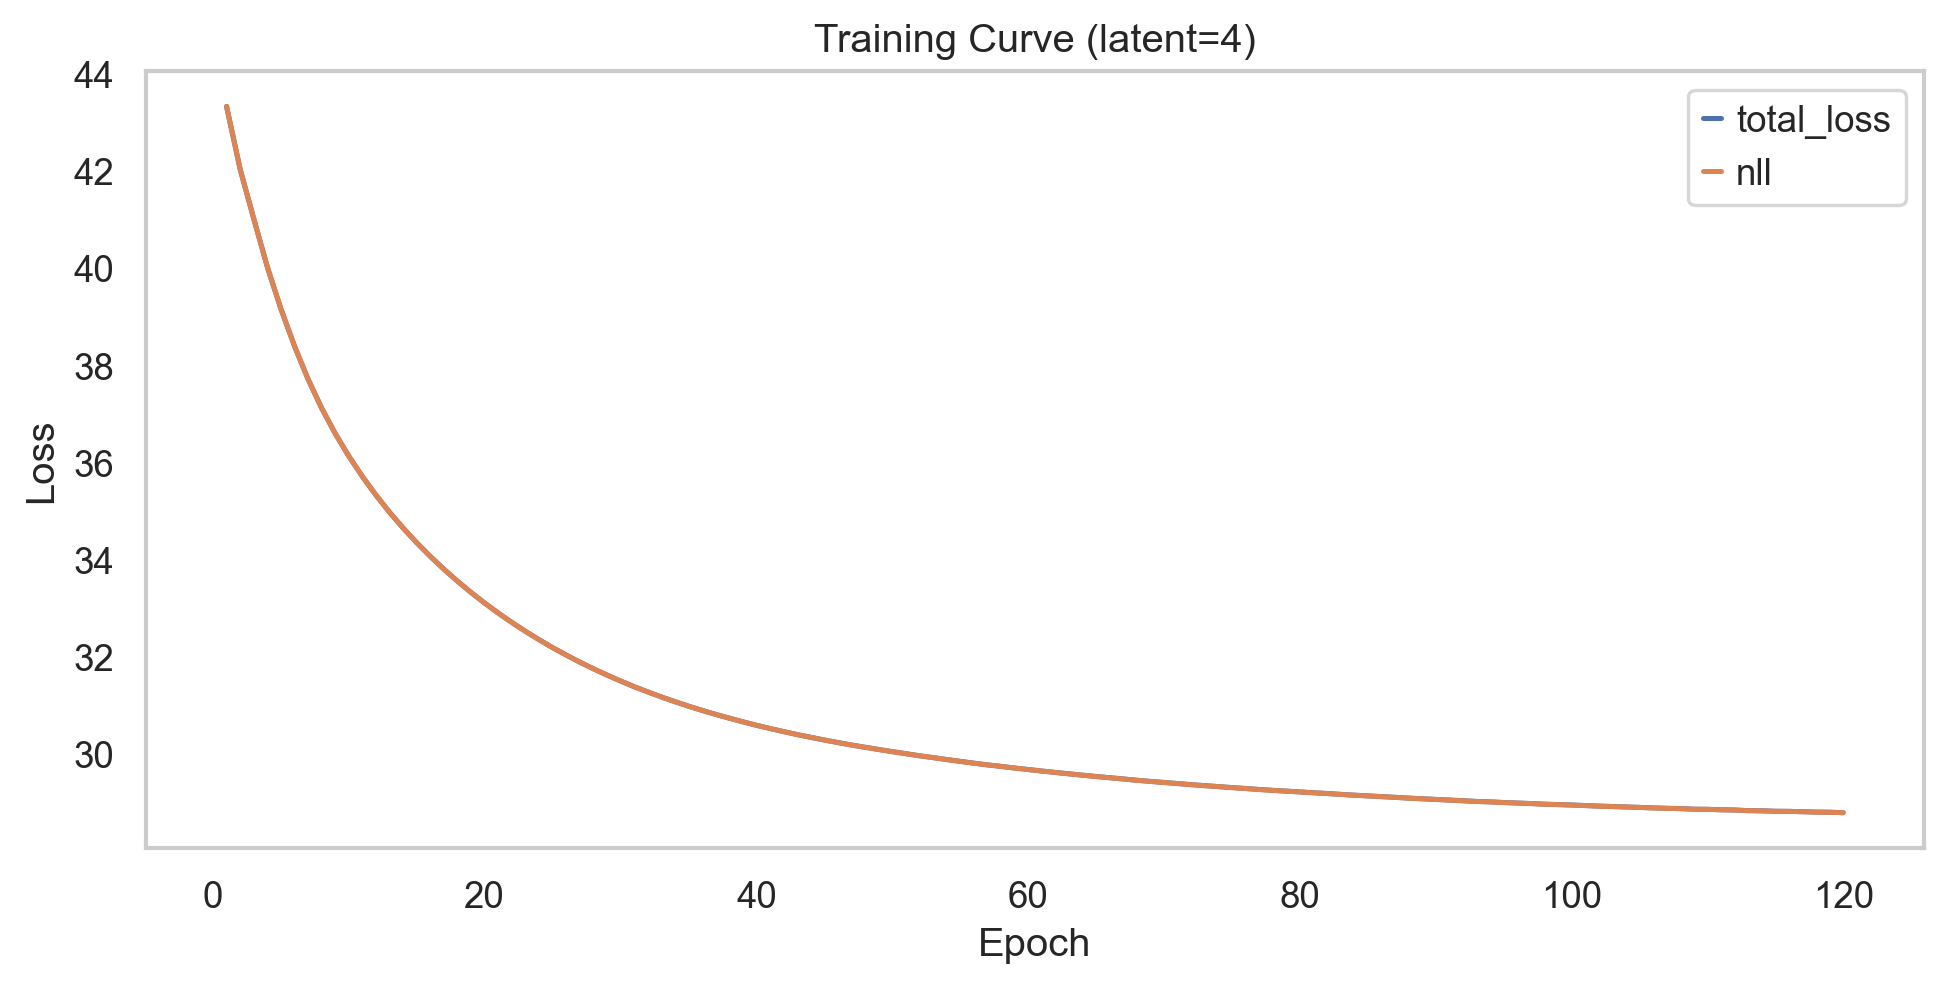

Resolved run directory: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4
Model checkpoint: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/model_best.pt


In [36]:
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device(DEVICE)
x_tensor = torch.from_numpy(adata_deconv.obsm['X_input_zscore'].astype(np.float32))
loader = DataLoader(TensorDataset(x_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

model = ProbabilisticArchetypalAutoencoder(
    n_markers=adata_deconv.n_vars,
    n_archetypes=LATENT_DIM,
    encoder_hidden_dims=(128, 64),
    activation='relu',
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def _safe_token(x) -> str:
    return str(x).replace('/', '-').replace(' ', '_').replace('.', 'p')

run_name = (
    f"variant-{_safe_token(FILE_VARIANT)}"
    f"_cells-{int(TARGET_TOTAL_CELLS)}"
    f"_noDot2-{int(EXCLUDE_SAMPLE_IDS_ENDING_WITH_DOT2)}"
    f"_latent-{LATENT_DIM}"
)
RUN_DIR = MODEL_CACHE_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = RUN_DIR / 'model_best.pt'
history_path = RUN_DIR / 'training_history.csv'
meta_path = RUN_DIR / 'model_meta.json'

# Backward-compatible lookup in older timestamped runs.
if REUSE_EXISTING_MODEL and (not FORCE_RETRAIN) and (not checkpoint_path.exists()):
    legacy_ckpts = sorted(
        (REPO_ROOT / 'outputs').glob(f'guy_latent{LATENT_DIM}_*/model_best.pt'),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if legacy_ckpts:
        RUN_DIR = legacy_ckpts[0].parent
        checkpoint_path = RUN_DIR / 'model_best.pt'
        history_path = RUN_DIR / 'training_history.csv'
        meta_path = RUN_DIR / 'model_meta.json'
        print(f'Using legacy checkpoint candidate: {checkpoint_path}')

def _compatible_meta(meta: dict) -> bool:
    try:
        if int(meta.get('latent_dim', -1)) != int(LATENT_DIM):
            return False
        if int(meta.get('n_markers', -1)) != int(adata_deconv.n_vars):
            return False
        marker_names = list(meta.get('marker_names', []))
        if marker_names and marker_names != list(adata_deconv.var_names):
            return False
        if str(meta.get('file_variant', FILE_VARIANT)) != str(FILE_VARIANT):
            return False
        return True
    except Exception:
        return False

loaded_existing = False
history_df = None

if REUSE_EXISTING_MODEL and (not FORCE_RETRAIN) and checkpoint_path.exists() and history_path.exists():
    meta_ok = True
    if meta_path.exists():
        with meta_path.open('r', encoding='utf-8') as f:
            meta_payload = json.load(f)
        meta_ok = _compatible_meta(meta_payload)

    if meta_ok:
        ckpt = torch.load(checkpoint_path, map_location=device)
        state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
        model.load_state_dict(state_dict)
        history_df = pd.read_csv(history_path)
        loaded_existing = True
        print(f'Loaded existing trained model: {checkpoint_path}')
    else:
        print('Found checkpoint, but metadata is incompatible with current dataset/config. Retraining.')

if not loaded_existing:
    history = []
    best_state = None
    best_loss = float('inf')
    epochs_without_improvement = 0

    epoch_bar = tqdm(range(1, MAX_EPOCHS + 1), desc='Training deconvolution model', dynamic_ncols=False)
    for epoch in epoch_bar:
        model.train()
        epoch_sums = {'loss': 0.0, 'nll': 0.0, 'entropy': 0.0, 'diversity': 0.0, 'var_reg': 0.0}
        count = 0

        for (xb,) in loader:
            xb = xb.to(device)
            optimizer.zero_grad(set_to_none=True)

            mean, logvar, w = model(xb)
            nll = gaussian_nll(xb, mean, logvar, reduction='mean')
            ent = entropy_penalty(w)
            div = diversity_penalty(model.archetype_means)
            var_reg = variance_regularization(model.archetype_logvars)
            loss = nll + LAMBDA_ENTROPY * ent + LAMBDA_DIVERSITY * div + LAMBDA_VAR * var_reg

            loss.backward()
            if GRAD_CLIP and GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            bs = int(xb.shape[0])
            epoch_sums['loss'] += float(loss.item()) * bs
            epoch_sums['nll'] += float(nll.item()) * bs
            epoch_sums['entropy'] += float(ent.item()) * bs
            epoch_sums['diversity'] += float(div.item()) * bs
            epoch_sums['var_reg'] += float(var_reg.item()) * bs
            count += bs

        row = {'epoch': epoch}
        for k in epoch_sums:
            row[k] = epoch_sums[k] / max(count, 1)
        history.append(row)

        if row['loss'] < best_loss:
            best_loss = row['loss']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        epoch_bar.set_postfix(
            loss=f"{row['loss']:.4f}",
            nll=f"{row['nll']:.4f}",
            ent=f"{row['entropy']:.4f}",
            div=f"{row['diversity']:.4f}",
            var=f"{row['var_reg']:.4f}",
            best=f"{best_loss:.4f}",
        )

        if epochs_without_improvement >= PATIENCE:
            print(f'Early stopping at epoch {epoch} (best loss={best_loss:.6f}).')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    # Persist checkpoint/history for future reuse.
    torch.save({'model_state_dict': model.state_dict(), 'best_loss': float(best_loss)}, checkpoint_path)
    history_df.to_csv(history_path, index=False)

    meta_payload = {
        'latent_dim': int(LATENT_DIM),
        'n_markers': int(adata_deconv.n_vars),
        'marker_names': list(adata_deconv.var_names),
        'file_variant': str(FILE_VARIANT),
        'target_total_cells': int(TARGET_TOTAL_CELLS),
        'exclude_dot2': bool(EXCLUDE_SAMPLE_IDS_ENDING_WITH_DOT2),
        'excluded_markers': list(EXCLUDED_MARKERS),
    }
    with meta_path.open('w', encoding='utf-8') as f:
        json.dump(meta_payload, f, indent=2)

    print(f'Saved trained model to: {checkpoint_path}')
else:
    print('Skipping retraining because a compatible trained model was found and FORCE_RETRAIN=False.')

display(history_df.tail())

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(history_df['epoch'], history_df['loss'], label='total_loss')
ax.plot(history_df['epoch'], history_df['nll'], label='nll')
ax.set_title('Training Curve (latent=4)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)
plt.show()

print('Resolved run directory:', RUN_DIR)
print('Model checkpoint:', checkpoint_path)


## Write Deconvolution Outputs into AnnData (`obs` + `obsm`)

In [37]:
model.eval()
pred_loader = DataLoader(TensorDataset(x_tensor), batch_size=4096, shuffle=False, drop_last=False)

all_mean = []
all_logvar = []
all_weights = []
with torch.no_grad():
    for (xb,) in pred_loader:
        xb = xb.to(device)
        mean_t, logvar_t, w_t = model(xb)
        all_mean.append(mean_t.cpu().numpy())
        all_logvar.append(logvar_t.cpu().numpy())
        all_weights.append(w_t.cpu().numpy())

mean_hat = np.vstack(all_mean).astype(np.float32)
logvar_hat = np.vstack(all_logvar).astype(np.float32)
weights = np.vstack(all_weights).astype(np.float32)

weight_cols = [f'w_{i}' for i in range(weights.shape[1])]
for i, col in enumerate(weight_cols):
    adata_deconv.obs[col] = weights[:, i]

adata_deconv.obs['dominant_archetype'] = np.array(weight_cols)[np.argmax(weights, axis=1)]
adata_deconv.obs['weight_entropy'] = -(weights * np.log(weights + 1e-10)).sum(axis=1)
adata_deconv.obs['max_weight'] = weights.max(axis=1)
adata_deconv.obs['dominant_archetype'] = adata_deconv.obs['dominant_archetype'].astype('category')

adata_deconv.obsm['X_weights'] = weights
adata_deconv.obsm['X_recon_mean_z'] = mean_hat
adata_deconv.obsm['X_recon_logvar_z'] = logvar_hat

nll_per_cell = 0.5 * (logvar_hat + ((adata_deconv.obsm['X_input_zscore'] - mean_hat) ** 2) * np.exp(-logvar_hat) + np.log(2.0 * np.pi))
nll_per_cell = np.sum(nll_per_cell, axis=1)
adata_deconv.obs['recon_nll'] = nll_per_cell

print('AnnData now contains deconvolution outputs.')
print('obs columns added:', weight_cols + ['dominant_archetype', 'weight_entropy', 'max_weight', 'recon_nll'])
print('obsm keys:', list(adata_deconv.obsm.keys()))
display(adata_deconv.obs[['sample_id', 'dominant_archetype', 'max_weight', 'weight_entropy', 'recon_nll'] + weight_cols].head())

AnnData now contains deconvolution outputs.
obs columns added: ['w_0', 'w_1', 'w_2', 'w_3', 'dominant_archetype', 'weight_entropy', 'max_weight', 'recon_nll']
obsm keys: ['X_input_zscore', 'X_weights', 'X_recon_mean_z', 'X_recon_logvar_z']


,sample_id,dominant_archetype,max_weight,weight_entropy,recon_nll,w_0,w_1,w_2,w_3
cell_id,,,,,,,,,
normalized_not_scaled_4.parquet__253889,4,w_2,0.461987,1.061488,22.782465,0.306661,0.230846,0.461987,0.000505
normalized_not_scaled_4.parquet__229982,4,w_0,0.659494,0.819814,26.038961,0.659494,0.024213,0.289777,0.026516
normalized_not_scaled_4.parquet__231079,4,w_0,0.448955,1.194956,16.301107,0.448955,0.104602,0.345009,0.101434
normalized_not_scaled_4.parquet__81974,4,w_0,0.499208,1.133865,13.945864,0.499208,0.052476,0.315160,0.133157
normalized_not_scaled_4.parquet__300457,4,w_0,0.440982,1.064471,14.870245,0.440982,0.019949,0.413816,0.125252


## Seaborn Diagnostics (Heatmaps + Histograms)

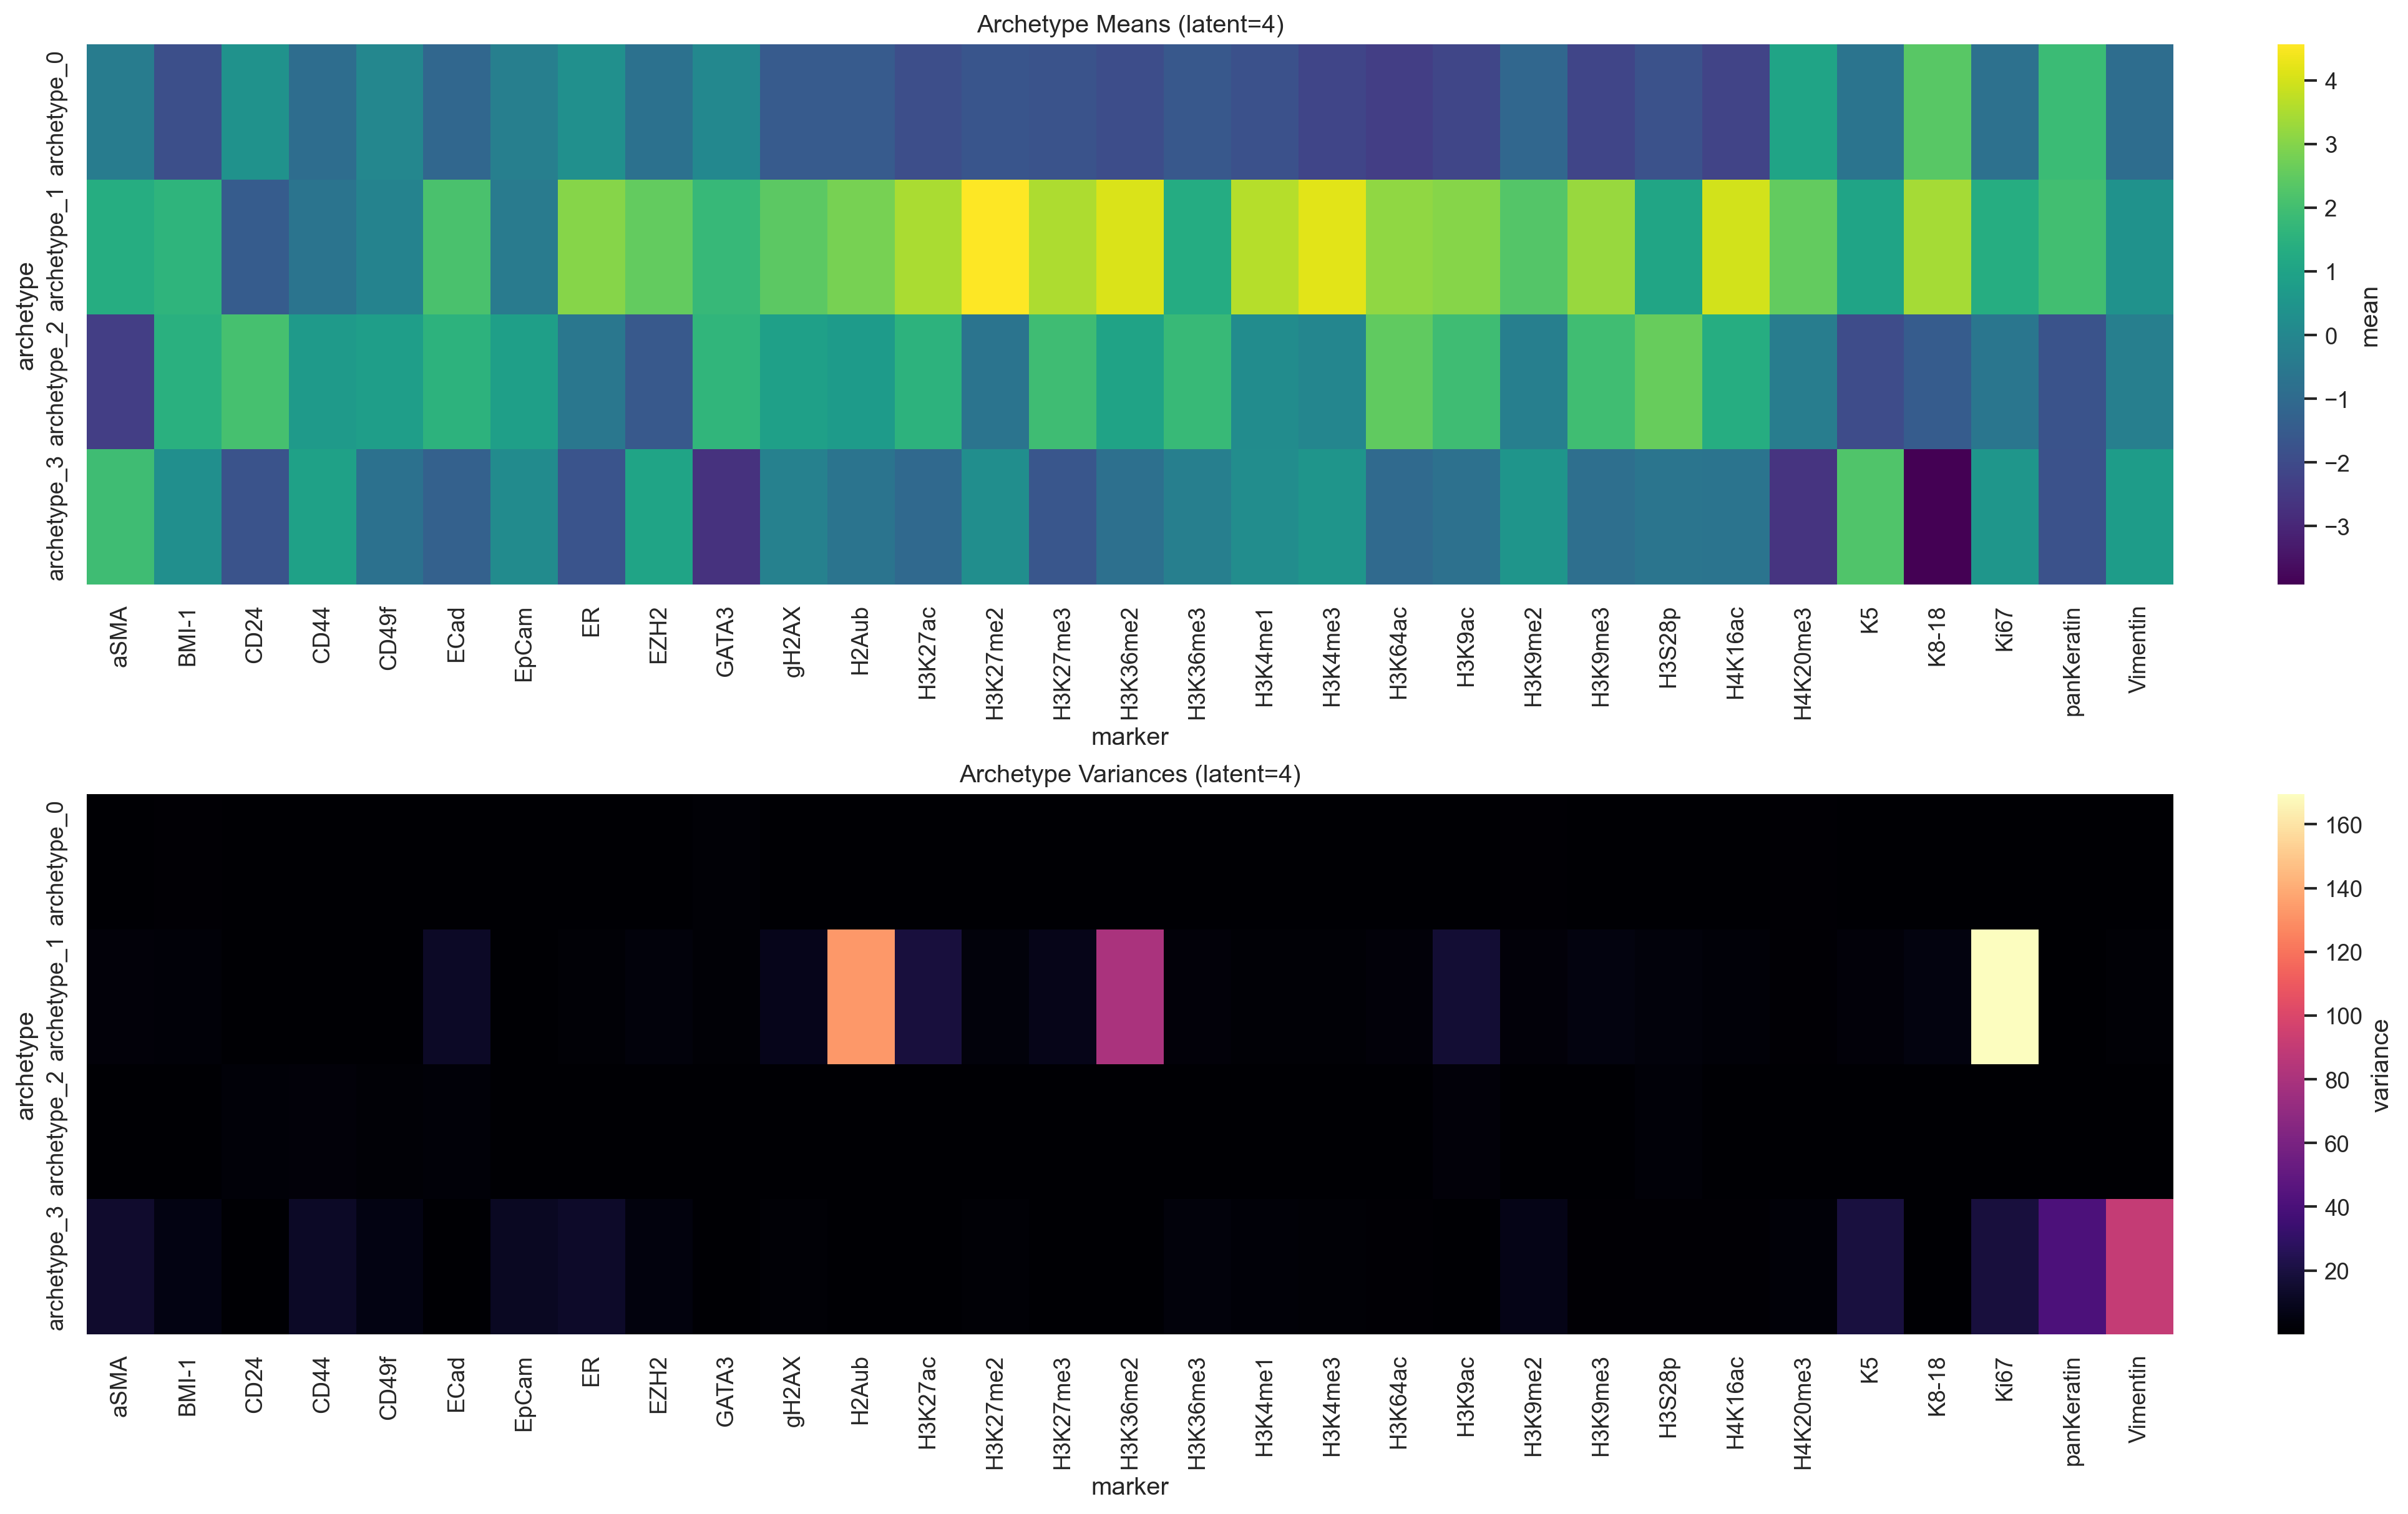

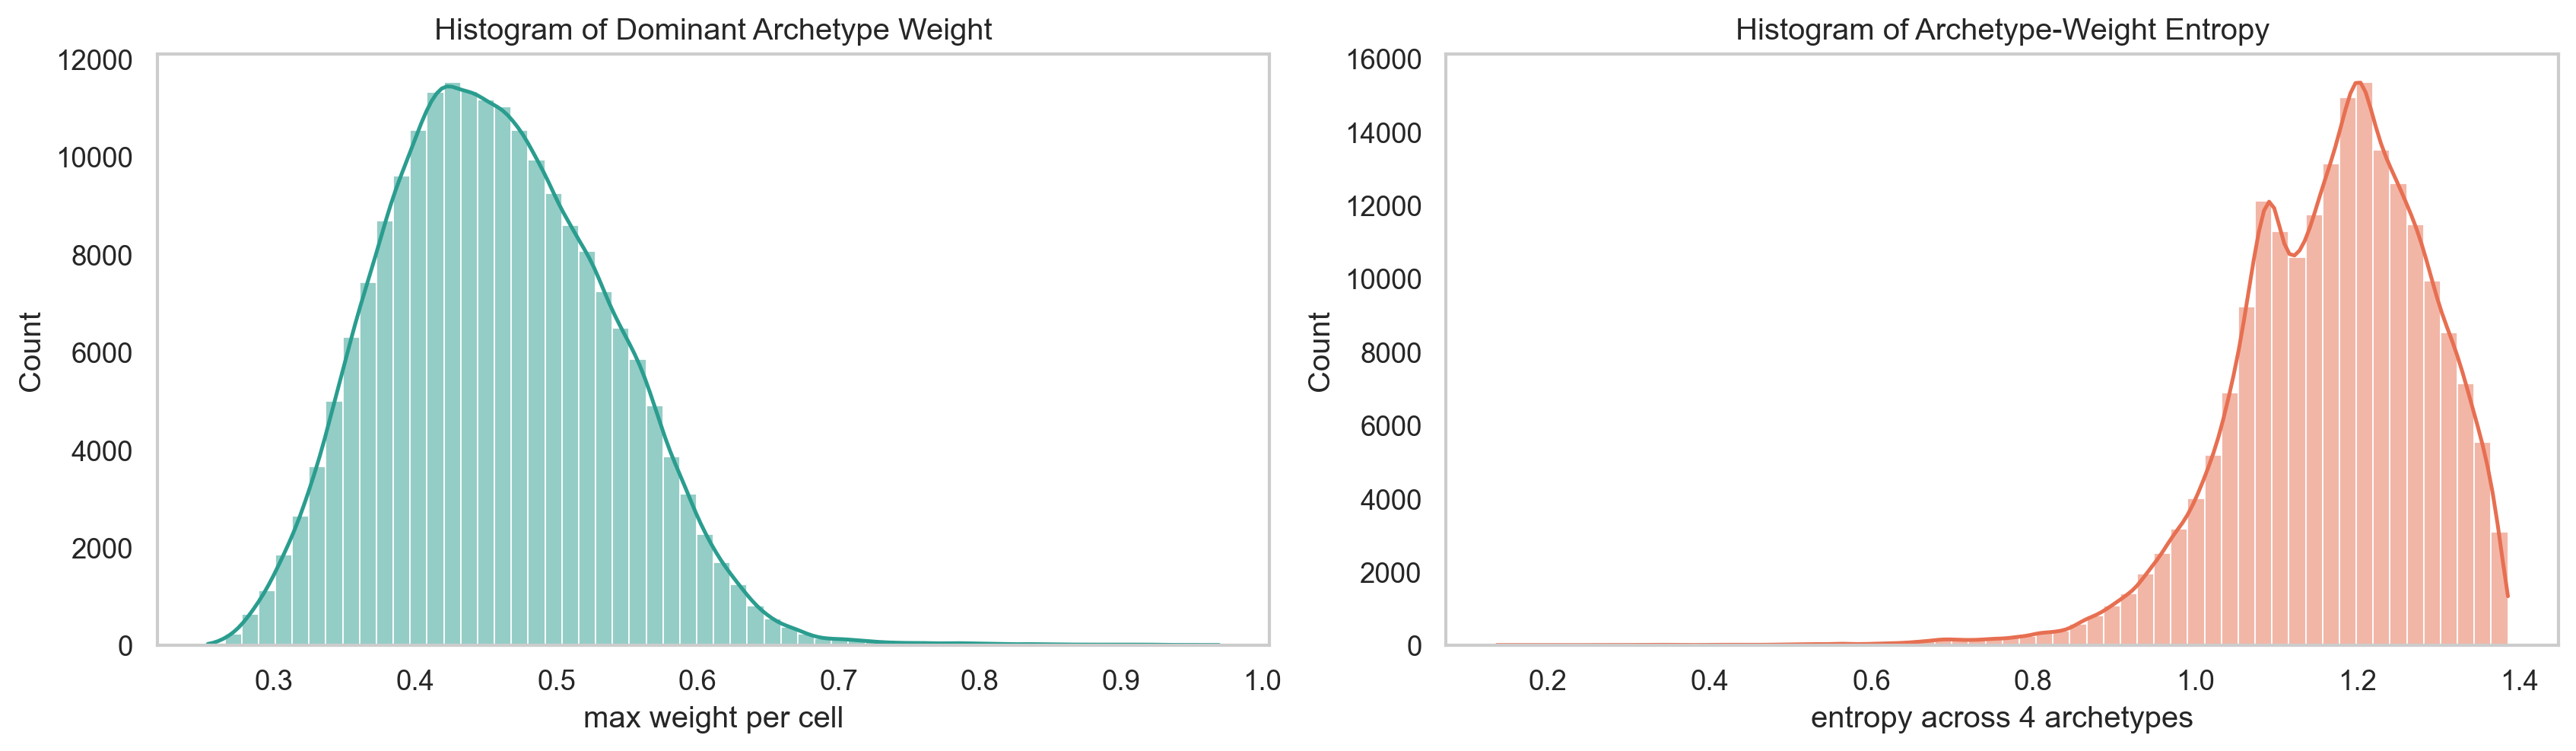

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_6980/1154448480.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_sample = adata_deconv.obs.groupby('sample_id')[weight_cols].mean().sort_index()


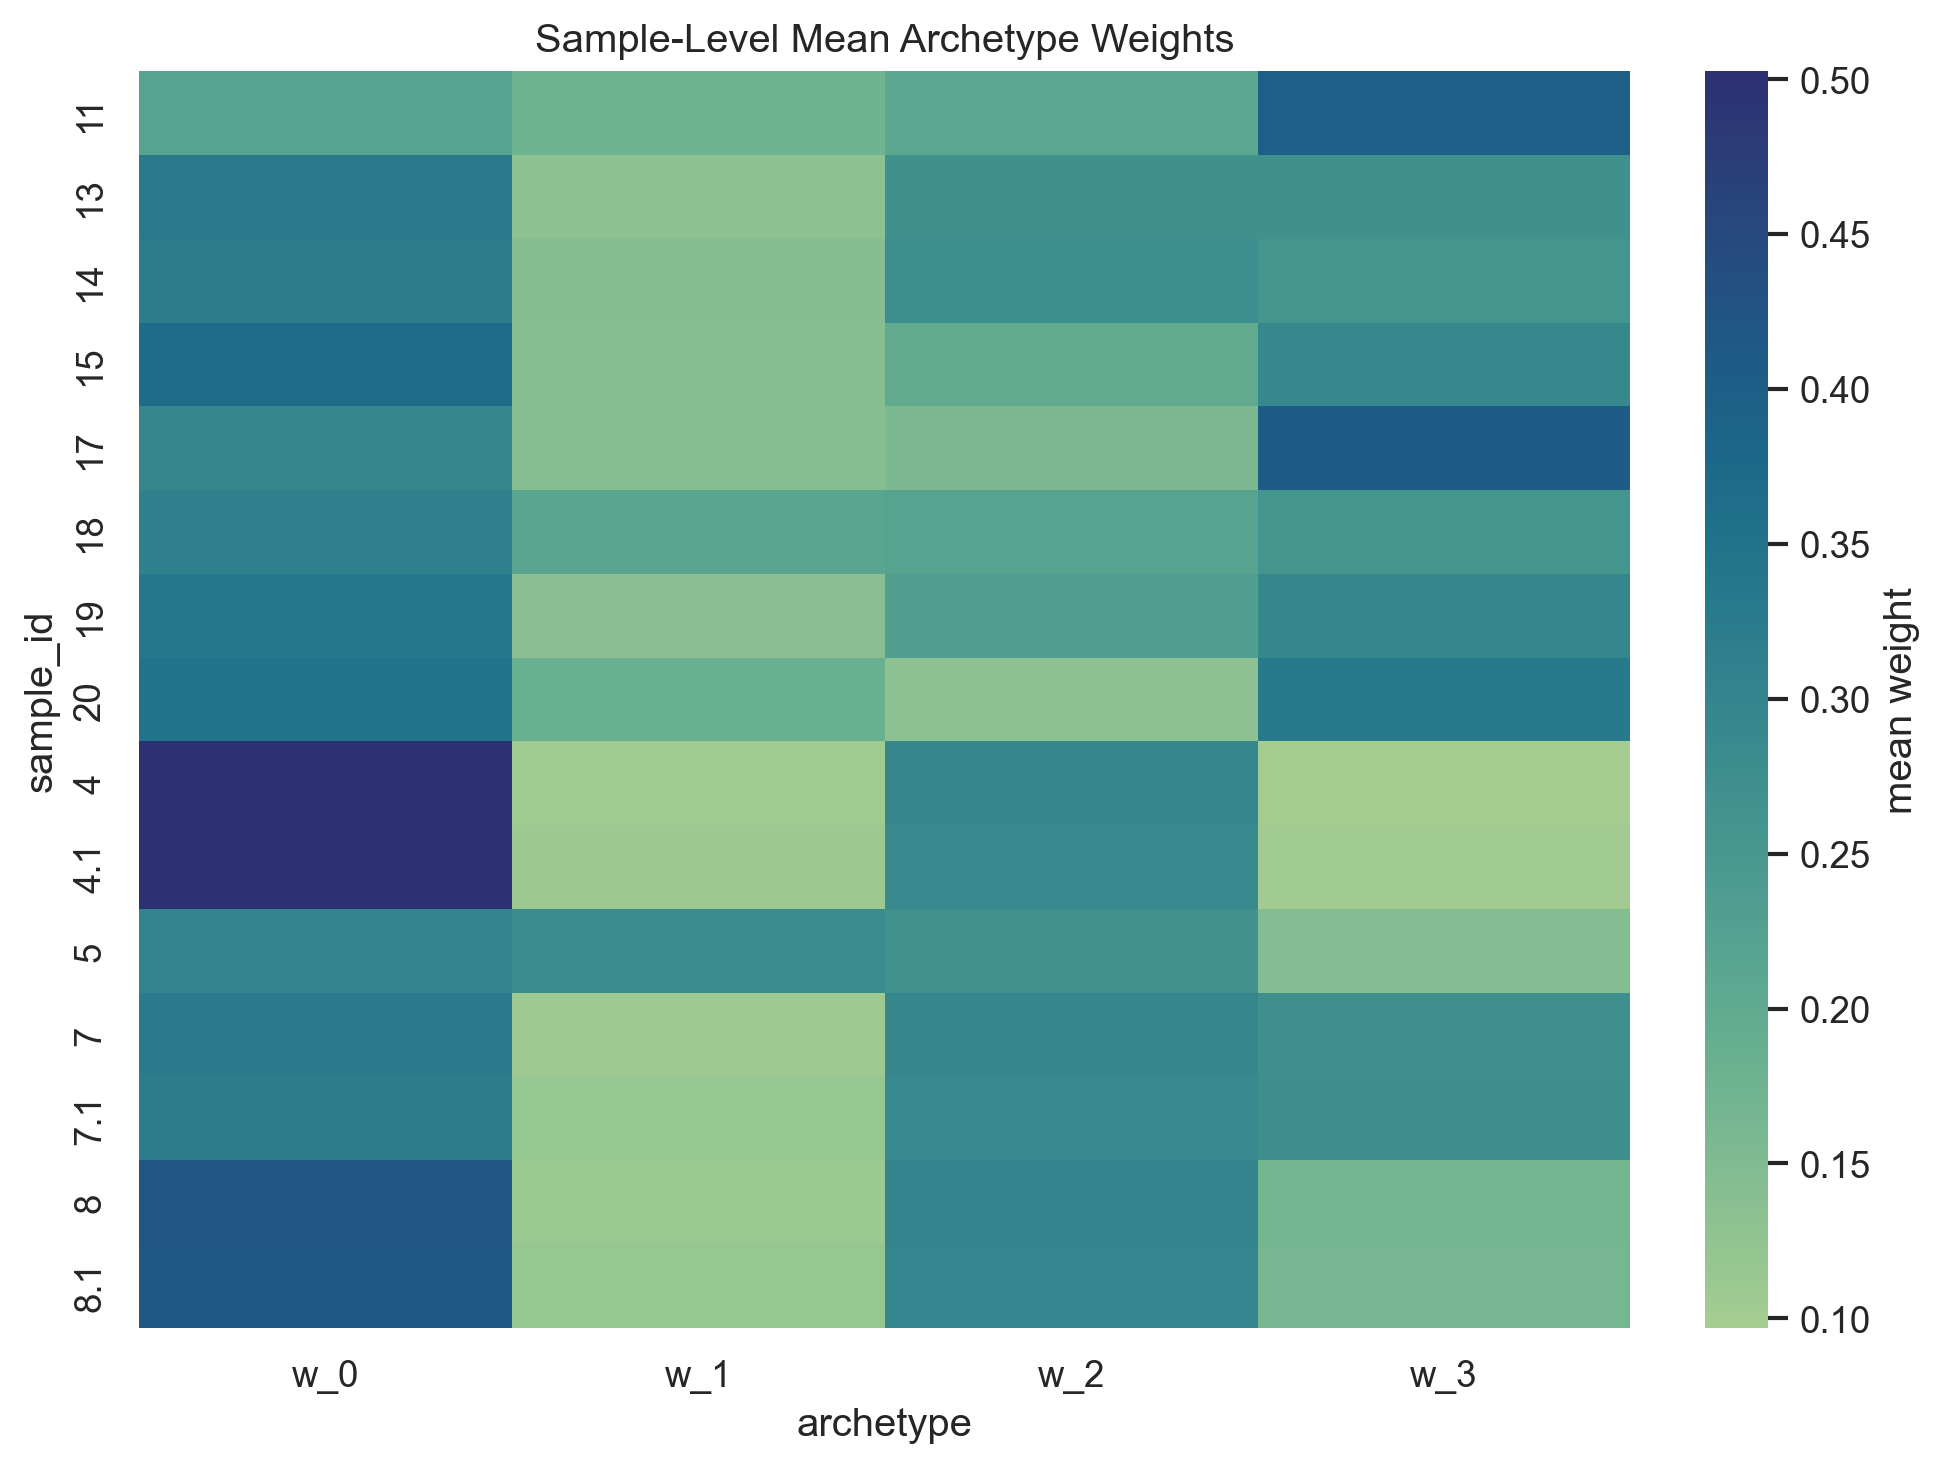

In [38]:
arch_means = model.archetype_means.detach().cpu().numpy()
arch_vars = np.exp(model.archetype_logvars.detach().cpu().numpy())

arch_mean_df = pd.DataFrame(arch_means, index=[f'archetype_{i}' for i in range(LATENT_DIM)], columns=adata_deconv.var_names)
arch_var_df = pd.DataFrame(arch_vars, index=[f'archetype_{i}' for i in range(LATENT_DIM)], columns=adata_deconv.var_names)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)
sns.heatmap(arch_mean_df, cmap='viridis', ax=axes[0], linewidths=0, cbar_kws={'label': 'mean'})
axes[0].set_title('Archetype Means (latent=4)')
axes[0].set_xlabel('marker')
axes[0].set_ylabel('archetype')
axes[0].grid(False)

sns.heatmap(arch_var_df, cmap='magma', ax=axes[1], linewidths=0, cbar_kws={'label': 'variance'})
axes[1].set_title('Archetype Variances (latent=4)')
axes[1].set_xlabel('marker')
axes[1].set_ylabel('archetype')
axes[1].grid(False)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.histplot(adata_deconv.obs['max_weight'], bins=60, kde=True, color='#2a9d8f', ax=axes[0])
axes[0].set_title('Histogram of Dominant Archetype Weight')
axes[0].set_xlabel('max weight per cell')
axes[0].grid(False)

sns.histplot(adata_deconv.obs['weight_entropy'], bins=60, kde=True, color='#e76f51', ax=axes[1])
axes[1].set_title('Histogram of Archetype-Weight Entropy')
axes[1].set_xlabel('entropy across 4 archetypes')
axes[1].grid(False)
plt.show()

by_sample = adata_deconv.obs.groupby('sample_id')[weight_cols].mean().sort_index()
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
sns.heatmap(by_sample, cmap='crest', linewidths=0, ax=ax, cbar_kws={'label': 'mean weight'})
ax.set_title('Sample-Level Mean Archetype Weights')
ax.set_xlabel('archetype')
ax.set_ylabel('sample_id')
ax.grid(False)
plt.show()

## Scanpy UMAP on Cell Weights

UMAP(low_memory=False, min_dist=0.2, n_neighbors=20, verbose=True)
Sun Apr  5 19:24:28 2026 Construct fuzzy simplicial set
Sun Apr  5 19:24:28 2026 Finding Nearest Neighbors
Sun Apr  5 19:24:28 2026 Building RP forest with 12 trees
Sun Apr  5 19:24:28 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	Stopping threshold met -- exiting after 2 iterations
Sun Apr  5 19:24:29 2026 Finished Nearest Neighbor Search
Sun Apr  5 19:24:29 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun Apr  5 19:24:30 2026 Finished embedding


UMAP transform -> X_umap_weights:   0%|          | 0/2 [00:00<?, ?it/s]

Sun Apr  5 19:24:30 2026 Worst tree score: 0.99025000
Sun Apr  5 19:24:30 2026 Mean tree score: 0.99111250
Sun Apr  5 19:24:30 2026 Best tree score: 0.99210000
Sun Apr  5 19:24:30 2026 Forward diversification reduced edges from 400000 to 100422
Sun Apr  5 19:24:30 2026 Reverse diversification reduced edges from 100422 to 100422
Sun Apr  5 19:24:30 2026 Degree pruning reduced edges from 95778 to 95778
Sun Apr  5 19:24:30 2026 Resorting data and graph based on tree order
Sun Apr  5 19:24:30 2026 Building and compiling search function


Epochs completed:   0%|            0/30 [00:00]

	completed  0  /  30 epochs
	completed  3  /  30 epochs
	completed  6  /  30 epochs
	completed  9  /  30 epochs
	completed  12  /  30 epochs
	completed  15  /  30 epochs
	completed  18  /  30 epochs
	completed  21  /  30 epochs
	completed  24  /  30 epochs
	completed  27  /  30 epochs


Epochs completed:   0%|            0/30 [00:00]

	completed  0  /  30 epochs
	completed  3  /  30 epochs
	completed  6  /  30 epochs
	completed  9  /  30 epochs
	completed  12  /  30 epochs
	completed  15  /  30 epochs
	completed  18  /  30 epochs
	completed  21  /  30 epochs
	completed  24  /  30 epochs
	completed  27  /  30 epochs
UMAP mode: subset-fit (20,000 cells) + chunked umap_transform on all 199,995 cells
UMAP helper info: {'fit_n': 20000, 'n_cells': 199995, 'input_rep': 'X_weights', 'output_rep': 'X_umap_weights', 'pca_components_used': 4}
Stored embeddings in obsm: ['X_umap_weights', 'X_umap']


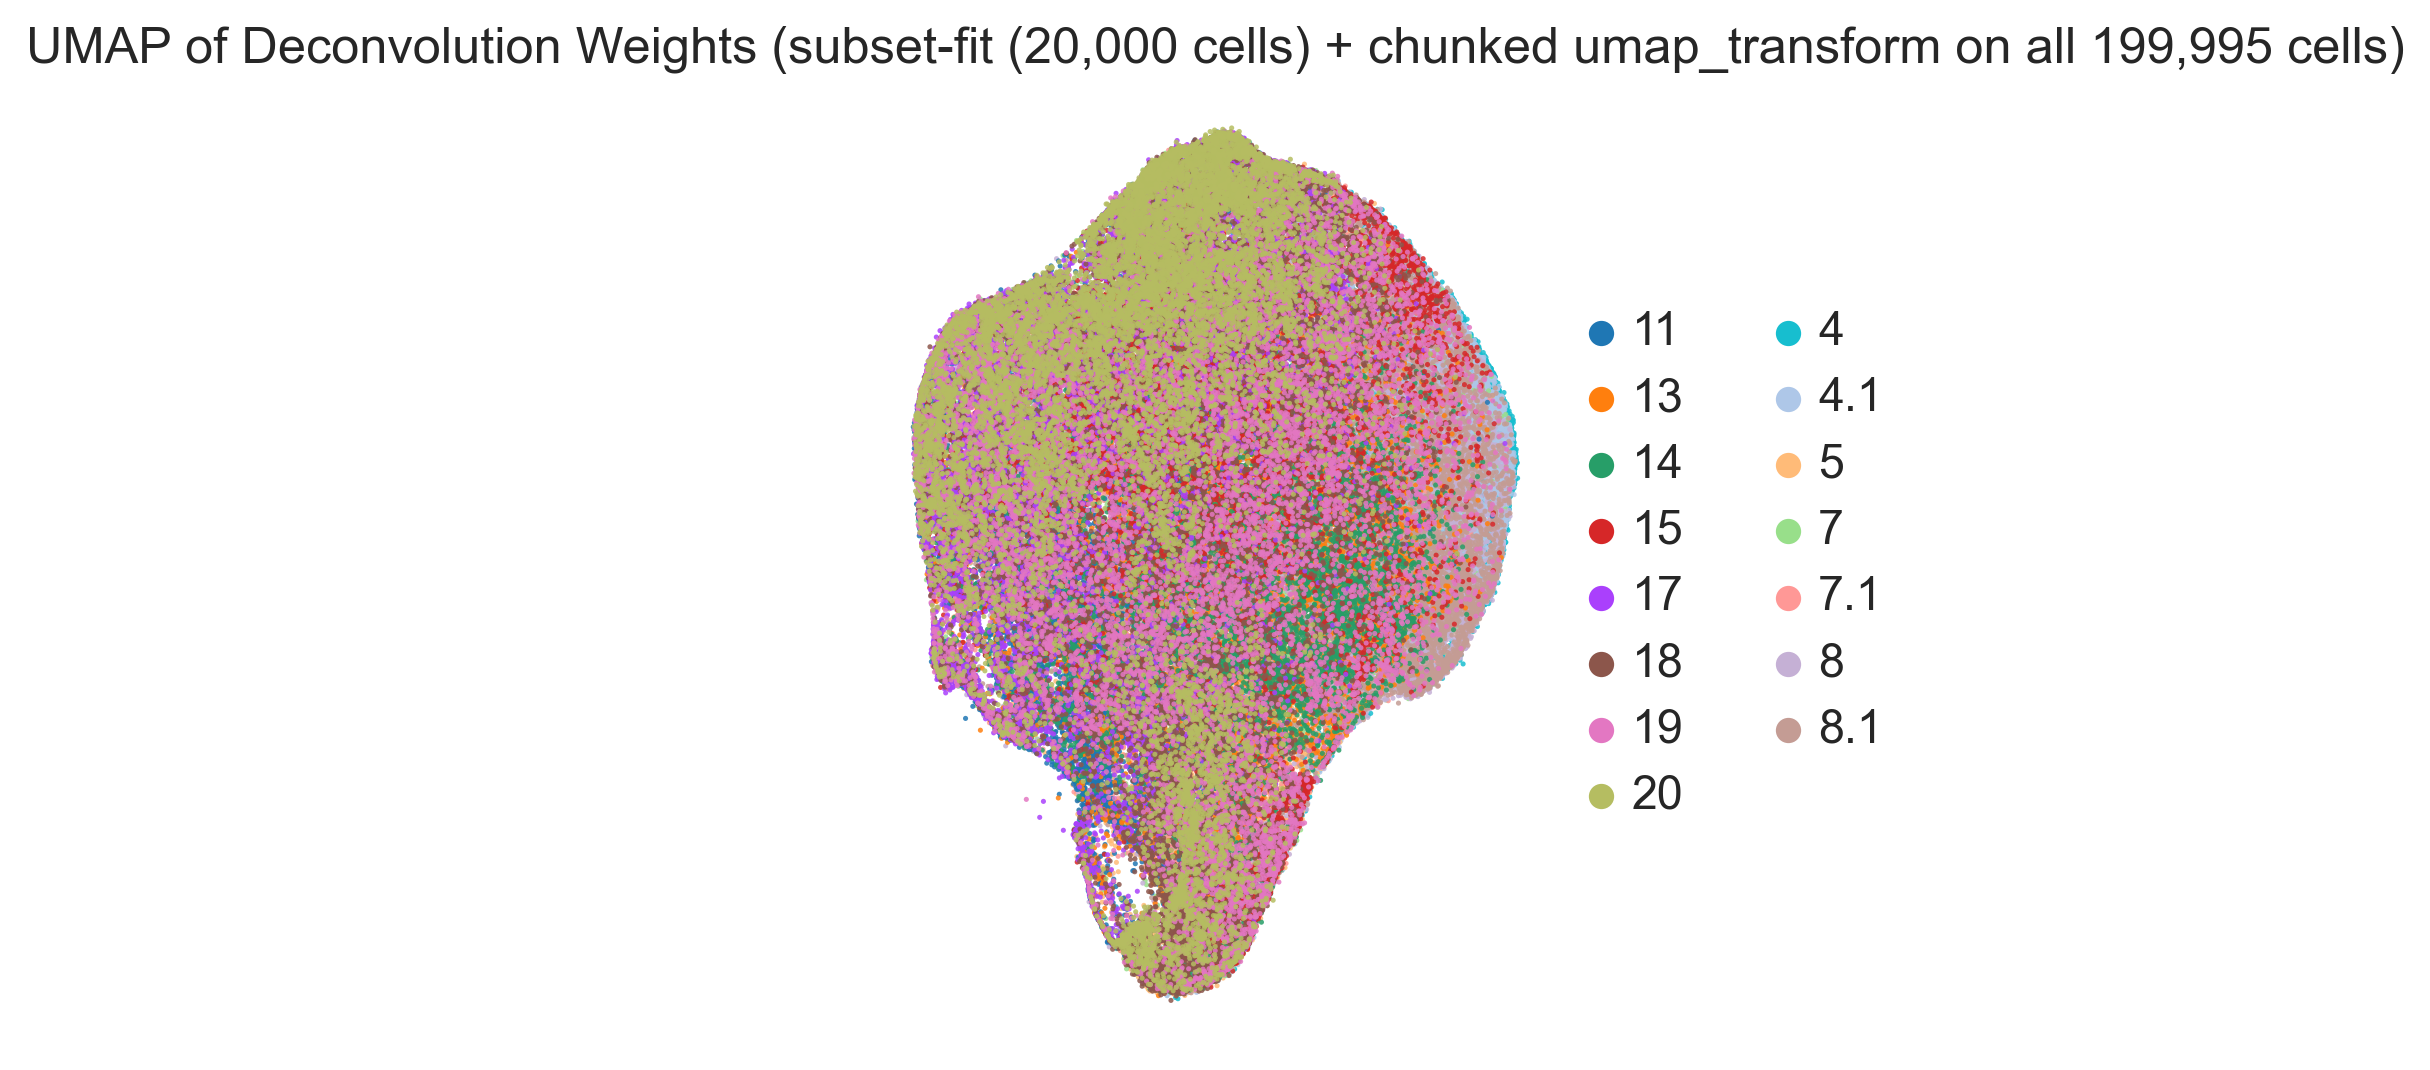

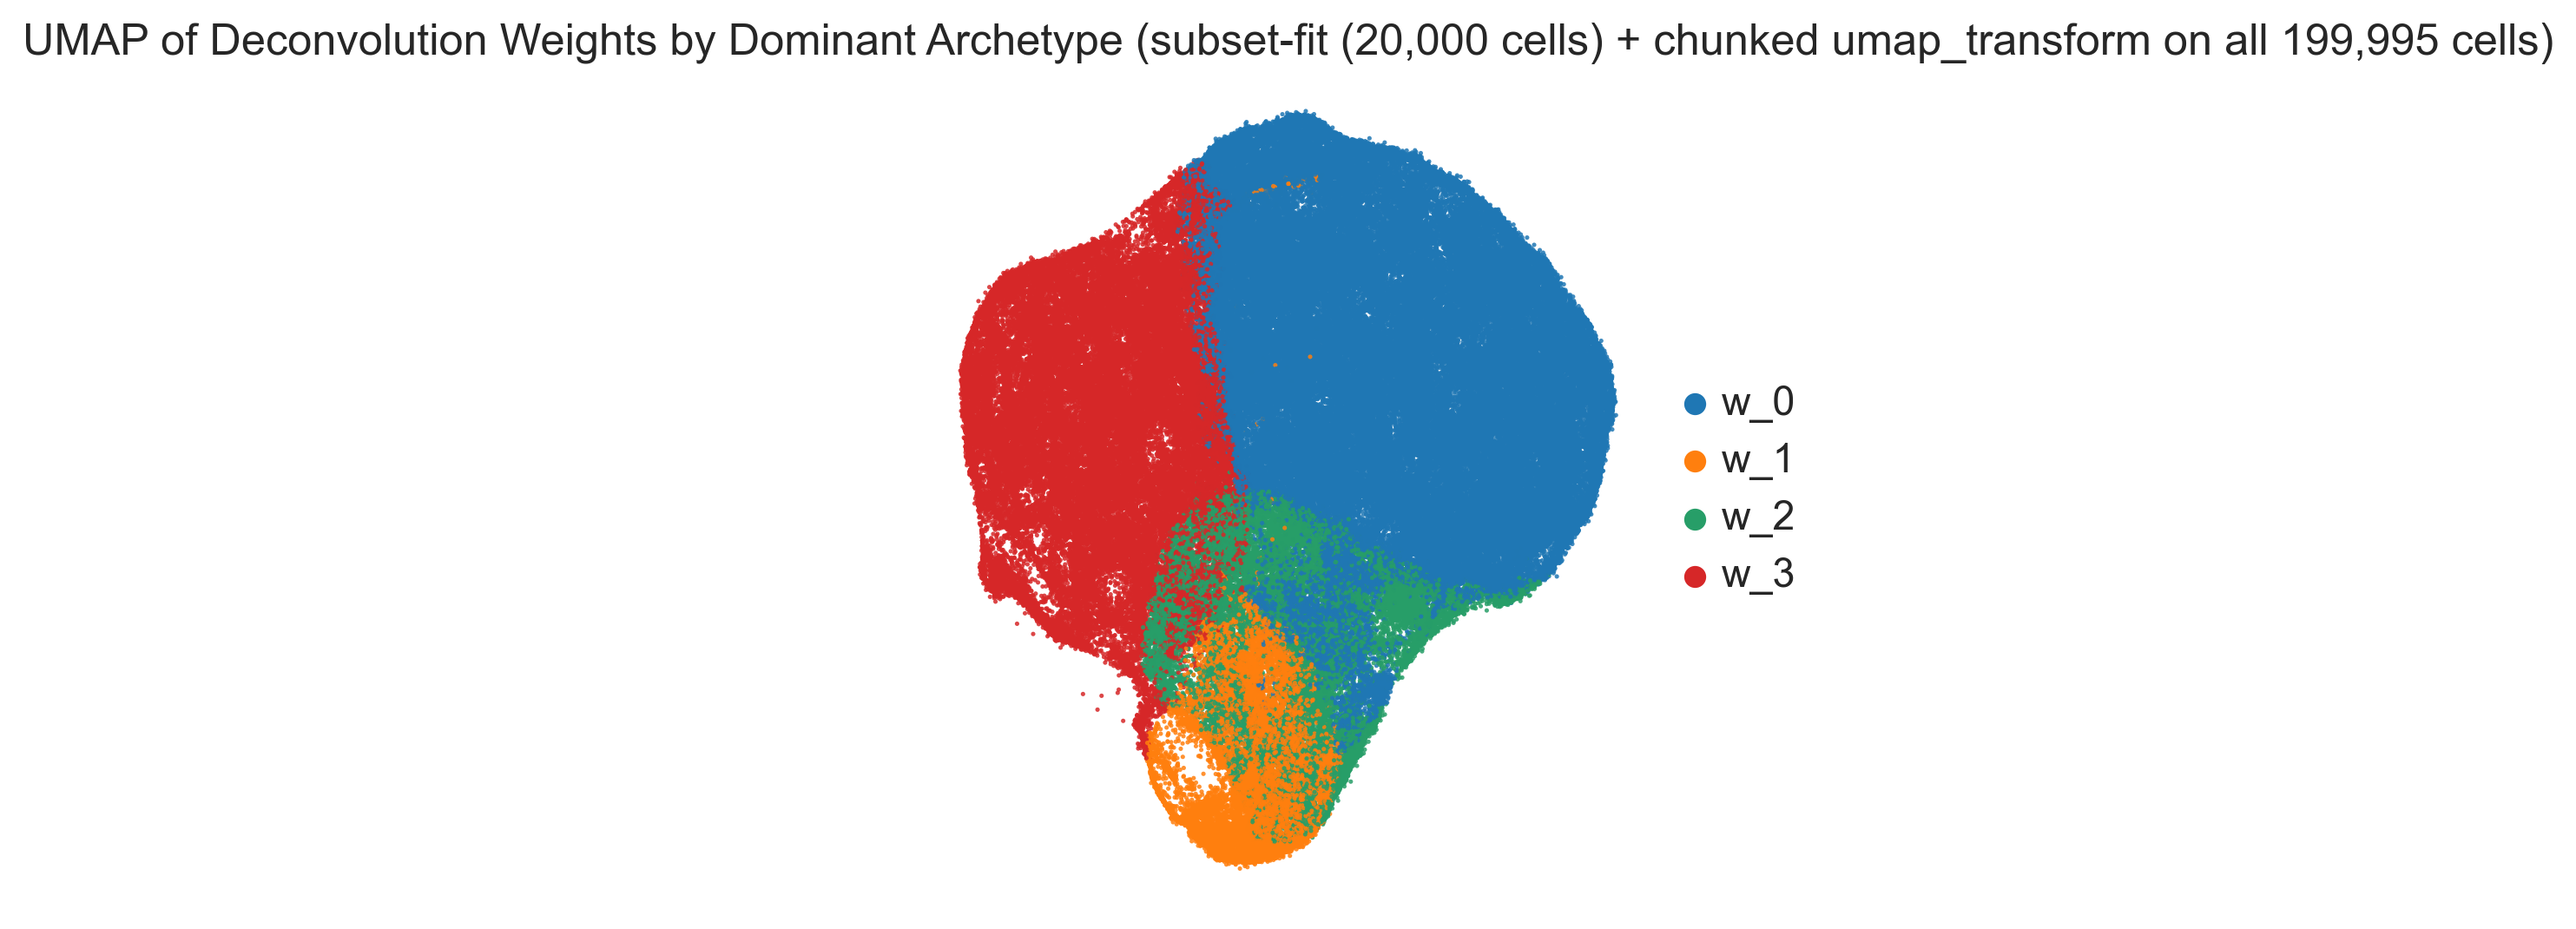

In [39]:
try:
    import scanpy as sc
except ImportError as exc:
    raise ImportError('scanpy is required: pip install scanpy') from exc

adata_deconv.obs['sample_id'] = adata_deconv.obs['sample_id'].astype(str).astype('category')

umap_info = fast_umap_transform_to_obsm(
    adata=adata_deconv,
    input_rep='X_weights',
    output_rep='X_umap_weights',
    group_obs='sample_id',
    fit_subset_n=UMAP_FIT_SUBSET_CELLS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    low_memory=UMAP_LOW_MEMORY,
    verbose=UMAP_VERBOSE,
    use_pca_precompression=UMAP_USE_PCA_PRECOMPRESSION,
    pca_components=UMAP_PCA_COMPONENTS,
    transform_chunk_size=UMAP_TRANSFORM_CHUNK_SIZE,
)

# Scanpy convention alias
adata_deconv.obsm['X_umap'] = adata_deconv.obsm['X_umap_weights'].copy()

mode_label = f"subset-fit ({umap_info['fit_n']:,} cells) + chunked umap_transform on all {umap_info['n_cells']:,} cells"
print('UMAP mode:', mode_label)
print('UMAP helper info:', umap_info)
print('Stored embeddings in obsm:', [k for k in adata_deconv.obsm.keys() if 'umap' in k.lower()])

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=130, facecolor='white')
sc.settings.autoshow = False

fig1 = sc.pl.embedding(
    adata_deconv,
    basis='umap_weights',
    color='sample_id',
    title=f'UMAP of Deconvolution Weights ({mode_label})',
    frameon=False,
    size=8,
    alpha=0.85,
    legend_loc='right margin',
    show=False,
    return_fig=True,
)
display(fig1)
plt.close(fig1)

fig2 = sc.pl.embedding(
    adata_deconv,
    basis='umap_weights',
    color='dominant_archetype',
    title=f'UMAP of Deconvolution Weights by Dominant Archetype ({mode_label})',
    frameon=False,
    size=8,
    alpha=0.85,
    legend_loc='right margin',
    show=False,
    return_fig=True,
)
display(fig2)
plt.close(fig2)


## Save Outputs

In [40]:
# umap_info = fast_umap_transform_to_obsm(
#     adata=adata_deconv,
#     input_rep='X',
#     output_rep='X_1',
#     group_obs='sample_id',
#     fit_subset_n=UMAP_FIT_SUBSET_CELLS,
#     n_neighbors=UMAP_N_NEIGHBORS,
#     min_dist=UMAP_MIN_DIST,
#     metric=UMAP_METRIC,
#     random_state=UMAP_RANDOM_STATE,
#     low_memory=UMAP_LOW_MEMORY,
#     verbose=UMAP_VERBOSE,
#     use_pca_precompression=UMAP_USE_PCA_PRECOMPRESSION,
#     pca_components=UMAP_PCA_COMPONENTS,
#     transform_chunk_size=100_000,
# )

In [49]:
adata_deconv.obs.groupby('sample_id').describe()['weight_entropy']

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_6980/1089647101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_deconv.obs.groupby('sample_id').describe()['weight_entropy']


,count,mean,std,min,25%,50%,75%,max
sample_id,,,,,,,,
11,13333.0,1.181136,0.115563,0.358489,1.106416,1.195422,1.258229,1.385723
13,13333.0,1.229116,0.090883,0.414202,1.183726,1.235580,1.291702,1.385493
14,13333.0,1.245826,0.084064,0.722487,1.197705,1.256164,1.309419,1.386151
15,13333.0,1.189154,0.098388,0.646971,1.122742,1.204504,1.262190,1.385517
17,13333.0,1.136701,0.125101,0.137404,1.065894,1.149715,1.210882,1.386164
18,13333.0,1.179533,0.123279,0.284239,1.109300,1.196754,1.268473,1.385646
19,13333.0,1.160342,0.109820,0.339339,1.094555,1.169650,1.234030,1.384955
20,13333.0,1.169919,0.119657,0.217787,1.098561,1.181164,1.251893,1.386084
4,13333.0,1.080375,0.118972,0.647756,1.005571,1.086742,1.162745,1.384509


In [41]:
out_dir = RUN_DIR / 'exports'
out_dir.mkdir(parents=True, exist_ok=True)

# Save AnnData with marker matrix in X, labels/weights in obs, embeddings in obsm.
adata_path = out_dir / 'adata_deconv_latent4.h5ad'
adata_deconv.write_h5ad(adata_path)

arch_mean_df.to_csv(out_dir / 'archetype_means.csv')
arch_var_df.to_csv(out_dir / 'archetype_vars.csv')
history_df.to_csv(out_dir / 'training_history_snapshot.csv', index=False)
adata_deconv.obs[['cell_id', 'sample_id'] + weight_cols + ['dominant_archetype', 'max_weight', 'weight_entropy', 'recon_nll']].to_csv(out_dir / 'cell_weights_latent4.csv', index=False)
pd.DataFrame(adata_deconv.obsm['X_umap_weights'], columns=['UMAP1', 'UMAP2'], index=adata_deconv.obs.index).reset_index(names='cell_id').to_csv(out_dir / 'umap_weights_latent4.csv', index=False)

config_snapshot = {
    'data_dir': str(DATA_DIR),
    'file_variant': FILE_VARIANT,
    'file_extension': FILE_EXTENSION,
    'excluded_markers': EXCLUDED_MARKERS,
    'latent_dim': LATENT_DIM,
    'target_total_cells': TARGET_TOTAL_CELLS,
    'device': DEVICE,
    'reuse_existing_model': bool(REUSE_EXISTING_MODEL),
    'force_retrain': bool(FORCE_RETRAIN),
    'resolved_run_dir': str(RUN_DIR),
}
with (out_dir / 'run_config_snapshot.json').open('w', encoding='utf-8') as f:
    json.dump(config_snapshot, f, indent=2)

print('Saved exports to:', out_dir)
print(' -', adata_path)
print(' -', out_dir / 'archetype_means.csv')
print(' -', out_dir / 'archetype_vars.csv')
print(' -', out_dir / 'cell_weights_latent4.csv')
print(' -', out_dir / 'umap_weights_latent4.csv')


Saved exports to: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/exports
 - /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/exports/adata_deconv_latent4.h5ad
 - /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/exports/archetype_means.csv
 - /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/exports/archetype_vars.csv
 - /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/exports/cell_weights_latent4.csv
 - /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not

## GPT-5.4 Diagnostic Analysis

Edit the prompt in the next cell, then run the API cell to generate an oncology-focused interpretation from the deconvolution outputs.


In [42]:
# Editable GPT-5.4 prompt (you can change this freely before running the API call cell).
GPT54_DIAGNOSTIC_MODEL = 'gpt-5.4'
GPT54_DIAGNOSTIC_MAX_TOKENS = 1800

GPT54_DIAGNOSTIC_PROMPT = f"""
You are a breast cancer computational oncology expert.

Analyze latent deconvolution results (latent dimension={LATENT_DIM}) from CyTOF marker data.
Interpret each archetype/program in terms of tumor cell-state programs where relevant
(e.g., basal-like, luminal-like, EMT-like, proliferative, stress/inflammatory, etc.).

Return STRICT JSON only (no markdown, no code fences) with this schema:
{{
  "global_summary": "short paragraph",
  "archetypes": [
    {{
      "archetype": "archetype_0",
      "interpretation": "short interpretation",
      "enriched_samples": ["sample_a", "sample_b"],
      "evidence_markers": ["marker1", "marker2"],
      "confidence": "low|medium|high"
    }}
  ],
  "hypotheses": ["..."],
  "caveats": ["..."],
  "next_analyses": ["..."]
}}

Requirements:
- Include one archetype object per latent program.
- Keep interpretations biologically grounded in the provided marker/program context.
- Be explicit about uncertainty.
""".strip()


In [43]:
import os
import json
import re
from pathlib import Path
from datetime import datetime
from html import escape

try:
    from openai import OpenAI
except ImportError as exc:
    raise ImportError('The openai package is required. Install with: pip install openai') from exc

from IPython.display import display, HTML


def load_openai_api_key_from_dotenv(env_path: Path | None = None) -> str:
    env_path = env_path or (Path.home() / '.env')
    if not env_path.exists():
        raise FileNotFoundError(f'Could not find .env file at: {env_path}')

    for raw_line in env_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('export '):
            line = line[len('export '):].strip()
        if '=' not in line:
            continue

        key, value = line.split('=', 1)
        if key.strip() == 'OPENAI_API_KEY':
            api_key = value.strip().strip('\"').strip("'")
            if api_key:
                return api_key

    raise ValueError('OPENAI_API_KEY was not found (or empty) in ~/.env')


def extract_response_text(response) -> str:
    text = getattr(response, 'output_text', None)
    if text:
        return text

    chunks: list[str] = []
    for item in getattr(response, 'output', []) or []:
        if getattr(item, 'type', None) != 'message':
            continue
        for content in getattr(item, 'content', []) or []:
            if getattr(content, 'type', None) == 'output_text':
                chunks.append(getattr(content, 'text', ''))
    return '\n'.join([c for c in chunks if c]).strip()


def extract_first_json_object(text: str) -> dict:
    cleaned = text.strip()
    if cleaned.startswith('```'):
        cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned)
        cleaned = re.sub(r'\s*```$', '', cleaned)

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    match = re.search(r'\{[\s\S]*\}', cleaned)
    if not match:
        raise ValueError('Could not find a JSON object in model output.')

    return json.loads(match.group(0))


def event_get(event, key: str):
    if isinstance(event, dict):
        return event.get(key)
    return getattr(event, key, None)


def render_stream_panel(text: str, title: str = 'GPT-5.4 stream') -> str:
    safe = escape(text).replace('\n', '<br>')
    return (
        '<div style="border:1px solid #ddd; border-radius:8px; padding:10px; background:#fafafa;">'
        + f'<div style="font-weight:600; margin-bottom:8px;">{escape(title)}</div>'
        + f'<div style="height:280px; overflow-y:auto; font-family: ui-monospace, SFMono-Regular, Menlo, monospace; font-size:12px; line-height:1.45; white-space:normal;">{safe}</div>'
        + '</div>'
    )


openai_api_key = os.getenv('OPENAI_API_KEY') or load_openai_api_key_from_dotenv()
client = OpenAI(api_key=openai_api_key)

sample_weight_means = (
    adata_deconv.obs.groupby('sample_id')[weight_cols]
    .mean()
    .sort_index()
    .round(4)
)

program_extremes = {}
for i in range(arch_mean_df.shape[0]):
    row = arch_mean_df.iloc[i]
    program_extremes[f'archetype_{i}'] = {
        'top_markers': row.sort_values(ascending=False).head(8).index.tolist(),
        'bottom_markers': row.sort_values(ascending=True).head(5).index.tolist(),
    }

context_payload = {
    'n_cells': int(adata_deconv.n_obs),
    'n_markers': int(adata_deconv.n_vars),
    'latent_dim': int(LATENT_DIM),
    'weight_columns': list(weight_cols),
    'sample_mean_weights': sample_weight_means.to_dict(orient='index'),
    'top_bottom_markers_per_archetype': program_extremes,
}

messages = [
    {
        'role': 'system',
        'content': 'You are a precise scientific analyst for single-cell cancer programs. Ground your claims in the provided context and clearly state uncertainty. Output strict JSON only.',
    },
    {
        'role': 'user',
        'content': GPT54_DIAGNOSTIC_PROMPT + '\n\nContext JSON:\n' + json.dumps(context_payload, indent=2),
    },
]

print(f'Calling {GPT54_DIAGNOSTIC_MODEL} (streaming)...')
streamed_text_chunks: list[str] = []
final_response = None

stream_box = display(HTML(render_stream_panel('')), display_id=True)

if hasattr(client.responses, 'stream'):
    with client.responses.stream(
        model=GPT54_DIAGNOSTIC_MODEL,
        input=messages,
        max_output_tokens=GPT54_DIAGNOSTIC_MAX_TOKENS,
    ) as stream:
        rendered_chars = 0
        total_chars = 0
        for event in stream:
            event_type = event_get(event, 'type')
            if event_type == 'response.output_text.delta':
                delta = event_get(event, 'delta') or ''
                streamed_text_chunks.append(delta)
                total_chars += len(delta)
                if total_chars - rendered_chars >= 300:
                    stream_box.update(HTML(render_stream_panel(''.join(streamed_text_chunks))))
                    rendered_chars = total_chars
        final_response = stream.get_final_response()

    gpt54_diagnostic_text = ''.join(streamed_text_chunks).strip()
    if not gpt54_diagnostic_text:
        gpt54_diagnostic_text = extract_response_text(final_response)
    stream_box.update(HTML(render_stream_panel(gpt54_diagnostic_text, title='GPT-5.4 final response')))
else:
    print('Streaming API not available in this openai package version. Falling back to non-streaming call.')
    final_response = client.responses.create(
        model=GPT54_DIAGNOSTIC_MODEL,
        input=messages,
        max_output_tokens=GPT54_DIAGNOSTIC_MAX_TOKENS,
    )
    gpt54_diagnostic_text = extract_response_text(final_response)
    stream_box.update(HTML(render_stream_panel(gpt54_diagnostic_text, title='GPT-5.4 final response')))

parsed = extract_first_json_object(gpt54_diagnostic_text)

archetype_rows = parsed.get('archetypes', [])
archetype_table = pd.DataFrame(archetype_rows)
if archetype_table.empty:
    raise ValueError('Model output JSON did not include archetype rows under key: archetypes')

for col in ['enriched_samples', 'evidence_markers']:
    if col in archetype_table.columns:
        archetype_table[col] = archetype_table[col].apply(
            lambda v: ', '.join(map(str, v)) if isinstance(v, list) else ('' if v is None else str(v))
        )

expected_arch = [f'archetype_{i}' for i in range(LATENT_DIM)]
if 'archetype' in archetype_table.columns:
    archetype_table['archetype'] = pd.Categorical(
        archetype_table['archetype'].astype(str),
        categories=expected_arch,
        ordered=True,
    )
    archetype_table = archetype_table.sort_values('archetype')

llm_out_dir = Path(out_dir) if 'out_dir' in globals() else (RUN_DIR / 'exports')
llm_out_dir.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
raw_path = llm_out_dir / f'gpt54_diagnostic_raw_{ts}.txt'
json_path = llm_out_dir / f'gpt54_diagnostic_structured_{ts}.json'
table_path = llm_out_dir / f'gpt54_diagnostic_archetype_table_{ts}.csv'

raw_path.write_text(gpt54_diagnostic_text, encoding='utf-8')
with json_path.open('w', encoding='utf-8') as f:
    json.dump(parsed, f, indent=2)
archetype_table.to_csv(table_path, index=False)

adata_deconv.uns['gpt54_diagnostic'] = {
    'model': GPT54_DIAGNOSTIC_MODEL,
    'prompt': GPT54_DIAGNOSTIC_PROMPT,
    'context': context_payload,
    'response_text': gpt54_diagnostic_text,
    'parsed': parsed,
    'saved_files': {
        'raw_text': str(raw_path),
        'structured_json': str(json_path),
        'archetype_table_csv': str(table_path),
    },
}

display_cols = [c for c in ['archetype', 'interpretation', 'enriched_samples', 'confidence'] if c in archetype_table.columns]
print('Archetype interpretation table:')
display(archetype_table[display_cols].reset_index(drop=True))
print('Saved GPT outputs to:', llm_out_dir)
print(' -', raw_path.name)
print(' -', json_path.name)
print(' -', table_path.name)


Calling gpt-5.4 (streaming)...


/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_6980/364371049.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_deconv.obs.groupby('sample_id')[weight_cols]


Archetype interpretation table:


,archetype,interpretation,enriched_samples,confidence
0,archetype_0,Luminal-like differentiated epithelial tumor p...,"4, 4.1, 8, 8.1, 15",high
1,archetype_1,Epigenetically active but weakly lineage-defin...,"5, 18, 20",low
2,archetype_2,Proliferative/mitotic epithelial subprogram wi...,"7, 8, 8.1, 4, 4.1",medium
3,archetype_3,Basal-like/EMT-like proliferative tumor progra...,"17, 11, 20, 15, 19",high


Saved GPT outputs to: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/guy_latent4_cache/variant-normalized_not_scaled_cells-200000_noDot2-1_latent-4/exports
 - gpt54_diagnostic_raw_20260405_192510.txt
 - gpt54_diagnostic_structured_20260405_192510.json
 - gpt54_diagnostic_archetype_table_20260405_192510.csv


## Notes

- This notebook intentionally uses the same source dataset conventions as `04_load_for_guy_umap.ipynb` (`for_guy` directory, file variant logic, and `.2` sample exclusion).
- Deconvolution latent dimension is fixed to `4`.
- `AnnData` conventions are preserved: marker matrix in `X`, metadata/weights in `obs`, embeddings in `obsm`.
- Retraining policy:
  - If `REUSE_EXISTING_MODEL=True`, `FORCE_RETRAIN=False`, and a compatible checkpoint exists, training is skipped.
  - Set `FORCE_RETRAIN=True` to force a new training run.
